# 🏁 03 — Baseline ML Models

**Fraud Detection Capstone — Sprint 1: Data Understanding & ML Baseline**

## 🎯 Goal
Train a simple baseline classifier and a first neural network on the processed data, establishing the reference point every later sprint improves against.


> ⚠️ **Data source note:** uses the processed splits saved by `02_data_preprocessing_feature_engineering.ipynb` (`data/processed/{train,val,test}.csv`). If those came from the synthetic placeholder (see notebook 01/02), these results are placeholder evidence only — re-run notebooks 01→03 after downloading the real `creditcard.csv` for final Sprint 1 results.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

SEED = 42
np.random.seed(SEED)

proc_dir = Path("data/processed")
train = pd.read_csv(proc_dir / "train.csv")
val = pd.read_csv(proc_dir / "val.csv")
test = pd.read_csv(proc_dir / "test.csv")

X_train, y_train = train.drop(columns=["Class"]), train["Class"]
X_val, y_val = val.drop(columns=["Class"]), val["Class"]
X_test, y_test = test.drop(columns=["Class"]), test["Class"]

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Train fraud rate: {y_train.mean()*100:.4f}%")


Train: (3506, 32) | Val: (751, 32) | Test: (752, 32)
Train fraud rate: 0.1711%


## 1. Baseline: Logistic Regression

A simple, fast, interpretable baseline. No resampling or class weighting yet — that's a deliberate Sprint 3 topic; this baseline establishes what "doing nothing special about imbalance" gets us.


In [2]:
baseline_model = LogisticRegression(max_iter=1000, random_state=SEED)
baseline_model.fit(X_train, y_train)

val_pred = baseline_model.predict(X_val)

baseline_metrics = {
    "accuracy": accuracy_score(y_val, val_pred),
    "precision": precision_score(y_val, val_pred, zero_division=0),
    "recall": recall_score(y_val, val_pred, zero_division=0),
    "f1": f1_score(y_val, val_pred, zero_division=0),
}
for k, v in baseline_metrics.items():
    print(f"{k:>10}: {v:.4f}")

print("\nClassification report:")
print(classification_report(y_val, val_pred, zero_division=0))


  accuracy: 1.0000
 precision: 1.0000
    recall: 1.0000
        f1: 1.0000

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       750
           1       1.00      1.00      1.00         1

    accuracy                           1.00       751
   macro avg       1.00      1.00      1.00       751
weighted avg       1.00      1.00      1.00       751



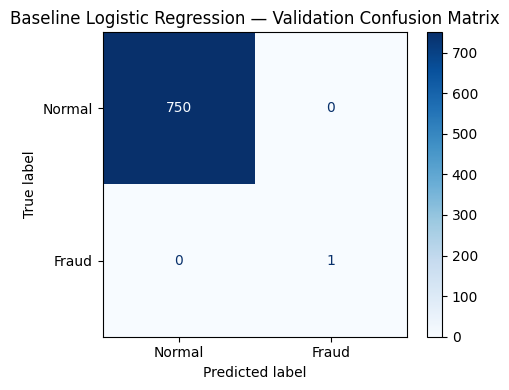

In [3]:
cm = confusion_matrix(y_val, val_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["Normal", "Fraud"]).plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Baseline Logistic Regression — Validation Confusion Matrix")
plt.tight_layout()
plt.show()


**Reading the confusion matrix:** with this severe an imbalance, accuracy will look deceptively high regardless of how well fraud itself is caught — the precision/recall/F1 numbers above (and the confusion matrix's false-negative count specifically) are the numbers that actually matter here. This gap is exactly why Sprint 3 exists.


## 2. First Neural Network (Keras)

A first dense network — architecture and training loop only, not yet the tuned/regularized version (that's Sprint 2). Sigmoid output + binary cross-entropy since this is binary classification; Adam optimizer; EarlyStopping to avoid wasted epochs.


In [4]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

tf.random.set_seed(SEED)

nn_model = Sequential([
    Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid"),
])

nn_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

Path("models").mkdir(exist_ok=True)
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint("models/sprint1_baseline_nn.keras", monitor="val_loss", save_best_only=True),
]

history = nn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=256,
    callbacks=callbacks,
    verbose=0,
)

print(f"Stopped after {len(history.history['loss'])} epochs (EarlyStopping)")


I0000 00:00:1788704278.507582     966 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788704278.589533     966 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788704280.079538     966 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Stopped after 30 epochs (EarlyStopping)


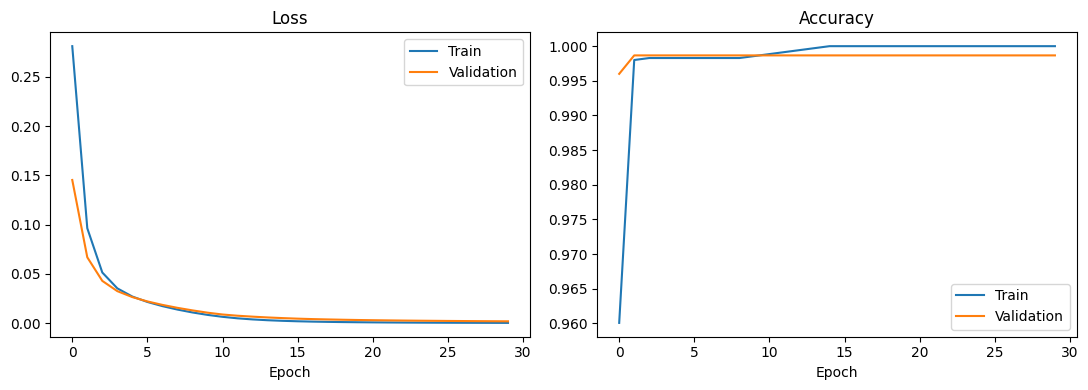

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history["loss"], label="Train")
axes[0].plot(history.history["val_loss"], label="Validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Train")
axes[1].plot(history.history["val_accuracy"], label="Validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


In [6]:
nn_val_pred_proba = nn_model.predict(X_val, verbose=0).ravel()
nn_val_pred = (nn_val_pred_proba >= 0.5).astype(int)

nn_metrics = {
    "accuracy": accuracy_score(y_val, nn_val_pred),
    "precision": precision_score(y_val, nn_val_pred, zero_division=0),
    "recall": recall_score(y_val, nn_val_pred, zero_division=0),
    "f1": f1_score(y_val, nn_val_pred, zero_division=0),
}
for k, v in nn_metrics.items():
    print(f"{k:>10}: {v:.4f}")


  accuracy: 0.9987
 precision: 0.0000
    recall: 0.0000
        f1: 0.0000


## 3. Baseline Comparison Table

In [7]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression (baseline)", "Dense Neural Network"],
    "Accuracy": [baseline_metrics["accuracy"], nn_metrics["accuracy"]],
    "Precision": [baseline_metrics["precision"], nn_metrics["precision"]],
    "Recall": [baseline_metrics["recall"], nn_metrics["recall"]],
    "F1": [baseline_metrics["f1"], nn_metrics["f1"]],
})
comparison


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression (baseline),1.000000,1.0,1.0,1.0
1,Dense Neural Network,0.998668,0.0,0.0,0.0


## 📝 Sprint 1 Summary

- Established two reference points on the validation set: a Logistic Regression baseline and a first (untuned) dense neural network.
- Both models are saved for later comparison (`models/sprint1_baseline_nn.keras`); the Logistic Regression baseline's coefficients/predictions can be regenerated from this notebook directly since it isn't saved as a separate artifact.
- Accuracy alone is not the metric to optimize going forward — precision/recall/F1/AUC-PR (Sprint 3) are.

**Next:** Sprint 2 — improve the neural network's architecture, regularization, and training process, then compare against this baseline.
